## Customer Churn Prediction

#### Life cycle of ml project
- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

#### 1) Problem Statement
- Customer churn is a major challenge for telecom companies because acquiring new customers is often more expensive than retaining existing ones. The goal of this project is to develop a machine learning model that can predict whether a customer is likely to leave the company based on demographic information, account details, and service usage patterns. By identifying customers at risk of churn, the company can take proactive retention measures and reduce customer loss.

#### 2) Data Collection
- Dataset source-https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data
- The data consists of 7043 rows (customers) and 21 columns (features).

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame


In [3]:
df = pd.read_csv('data/customer_churn.csv')

### Show top 5 records

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Shape of dataset

In [5]:
df.shape

(7043, 21)

### 2.2 Dataset information

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

### there are no duplicated values in dataset

### 3.3 Check data types

In [ ]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Exploring data

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']
# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['SeniorCitizen', 'tenure', 'MonthlyCharges']

We have 18 categorical features : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


#### Data Cleaning

In [32]:
# Replace blank spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [33]:
#convert numeric to float
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])
# Impute the 11 missing values with 0 (since tenure is 0, they haven't paid anything yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [16]:
# Dropping 'customerID' as it is a unique identifier and holds no predictive power
df = df.drop(columns=['customerID'])

In [17]:
df.duplicated().sum()

np.int64(22)

In [21]:
df=df.drop_duplicates()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


### Data Visualization

In [24]:
# Set visualization style
sns.set_theme(style="whitegrid")

#### overall churn distribution

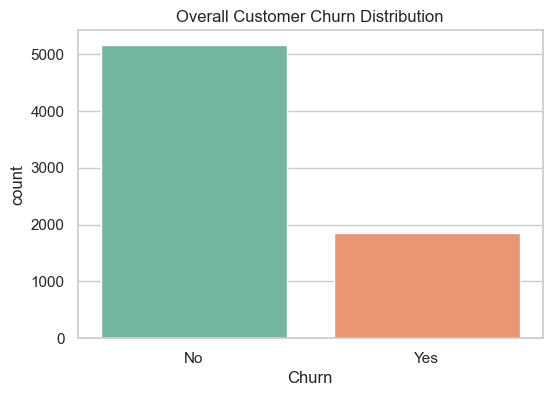

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Overall Customer Churn Distribution')
plt.show()

In [26]:
df['Churn'].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [27]:
100*df['Churn'].value_counts()/len(df['Churn'])

Churn
No     73.550776
Yes    26.449224
Name: count, dtype: float64

#### Insights
- Overall Churn Rate is High: Out of the 7,043 customers, roughly 26.54% have churned. This means the company is losing about 1 in 4 customers.

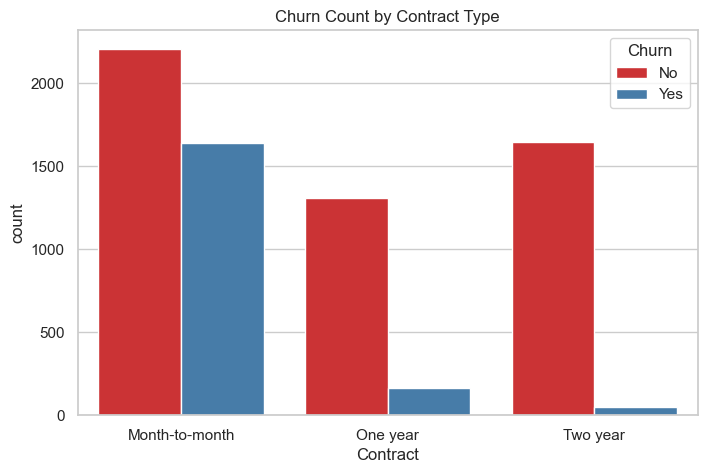

In [28]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn Count by Contract Type')
plt.show()

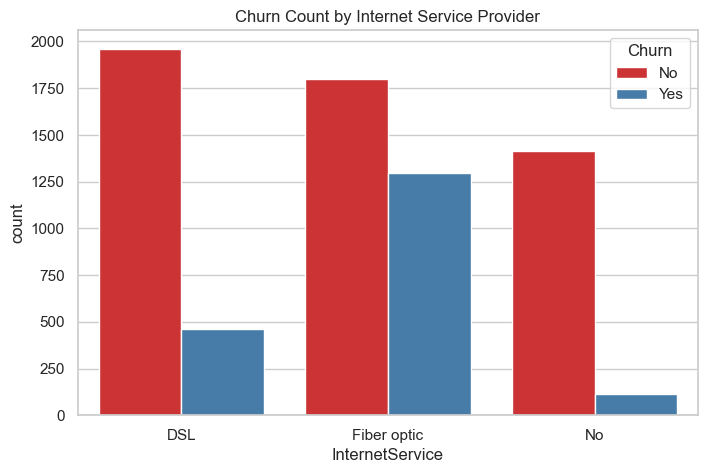

In [ ]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1')
plt.title('Churn Count by Internet Service Provider')
plt.show()

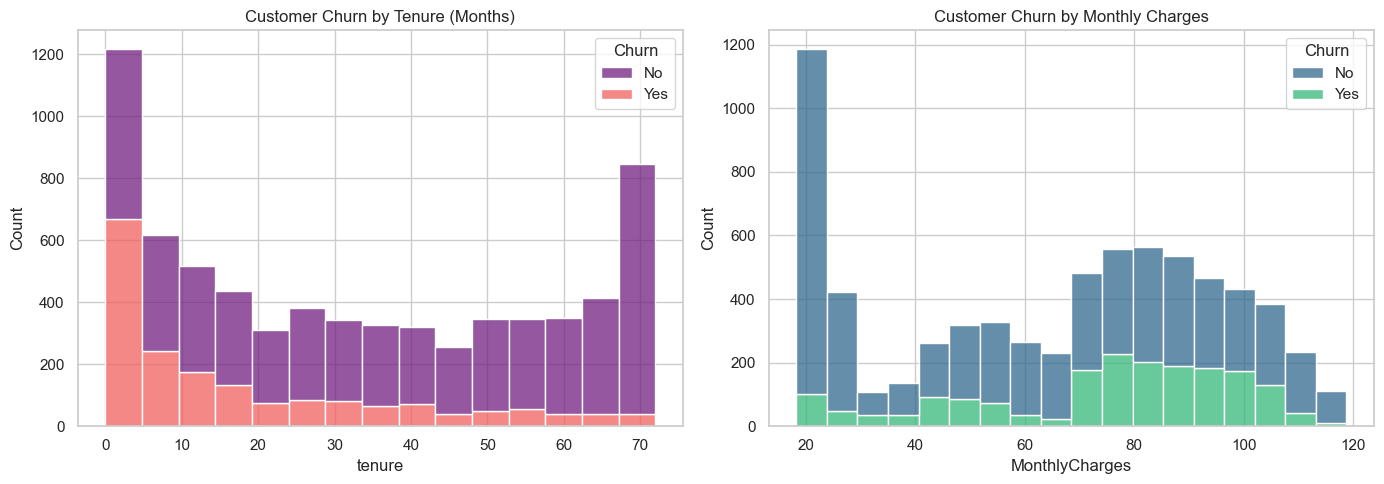

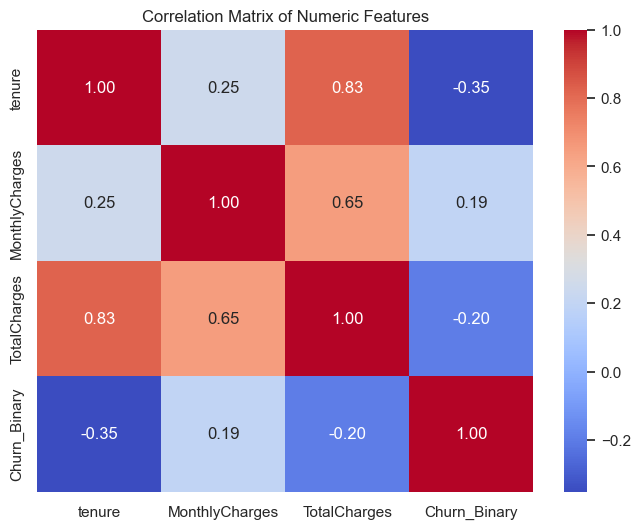

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure Distribution
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0], palette='magma')
axes[0].set_title('Customer Churn by Tenure (Months)')

# Monthly Charges Distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1], palette='viridis')
axes[1].set_title('Customer Churn by Monthly Charges')

plt.tight_layout()
plt.show()

# --- 5. Correlation Heatmap for Numeric Variables ---
plt.figure(figsize=(8, 6))
# Convert Churn to binary for correlation mapping
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})
corr_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

#### Insights
-Contract Type is the Biggest Factor: * 42.7% of customers on a Month-to-month contract churn.

- This drops drastically to 11.2% for One-year contracts and a mere 2.8% for Two-year contracts. Customers locked into longer-term contracts are highly loyal.

- Fiber Optic Customers are Leaving: Surprisingly, customers with Fiber optic internet have the highest churn rate at 41.89%. Compare this to DSL users (18.9% churn) and those without internet (7.4% churn). This suggests there may be a quality, reliability, or pricing issue specifically with the Fiber optic service.

- The Risk of the First Year (Tenure): New customers are the most vulnerable. Customers in their first 12 months (0-1 Year tenure) have a churn rate of 47.4%. As tenure increases, churn drops steadily; customers who have been with the company for 5-6 years have a churn rate of only 6.6%.

- Higher Monthly Charges Lead to Higher Churn

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0


In [ ]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Binary        0
dtype: int64

### Bivariate analysis

##### Numerical variables vs churn

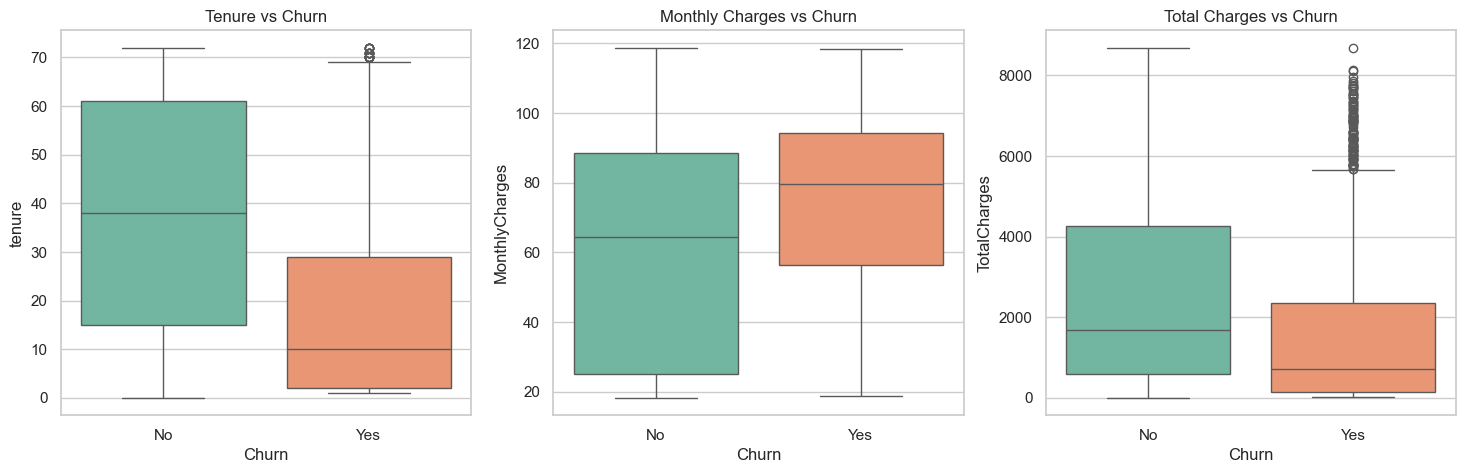

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Tenure vs Churn')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Charges vs Churn')
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2], palette='Set2')
axes[2].set_title('Total Charges vs Churn')
plt.show()

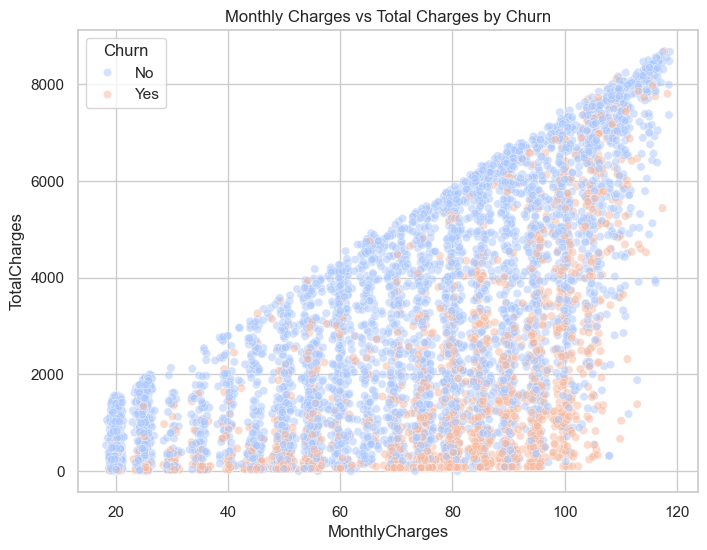

In [36]:
# Multivariate: MonthlyCharges vs TotalCharges colored by Churn
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.5, palette='coolwarm')
plt.title('Monthly Charges vs Total Charges by Churn')
plt.show()




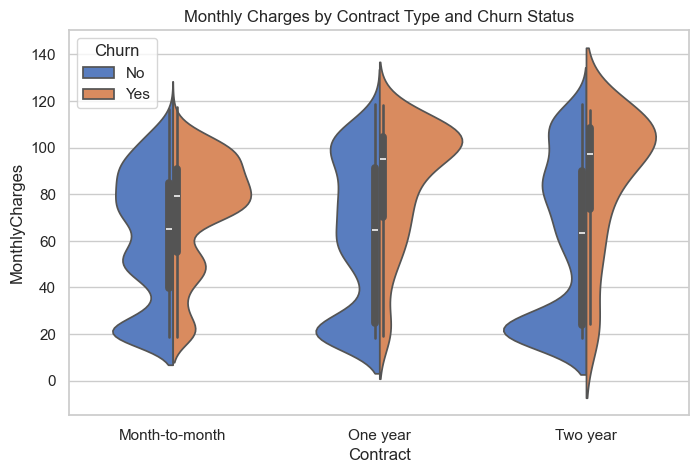

In [37]:
# Multivariate: Violin plot of MonthlyCharges by Contract and Churn
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', split=True, palette='muted')
plt.title('Monthly Charges by Contract Type and Churn Status')
plt.show()

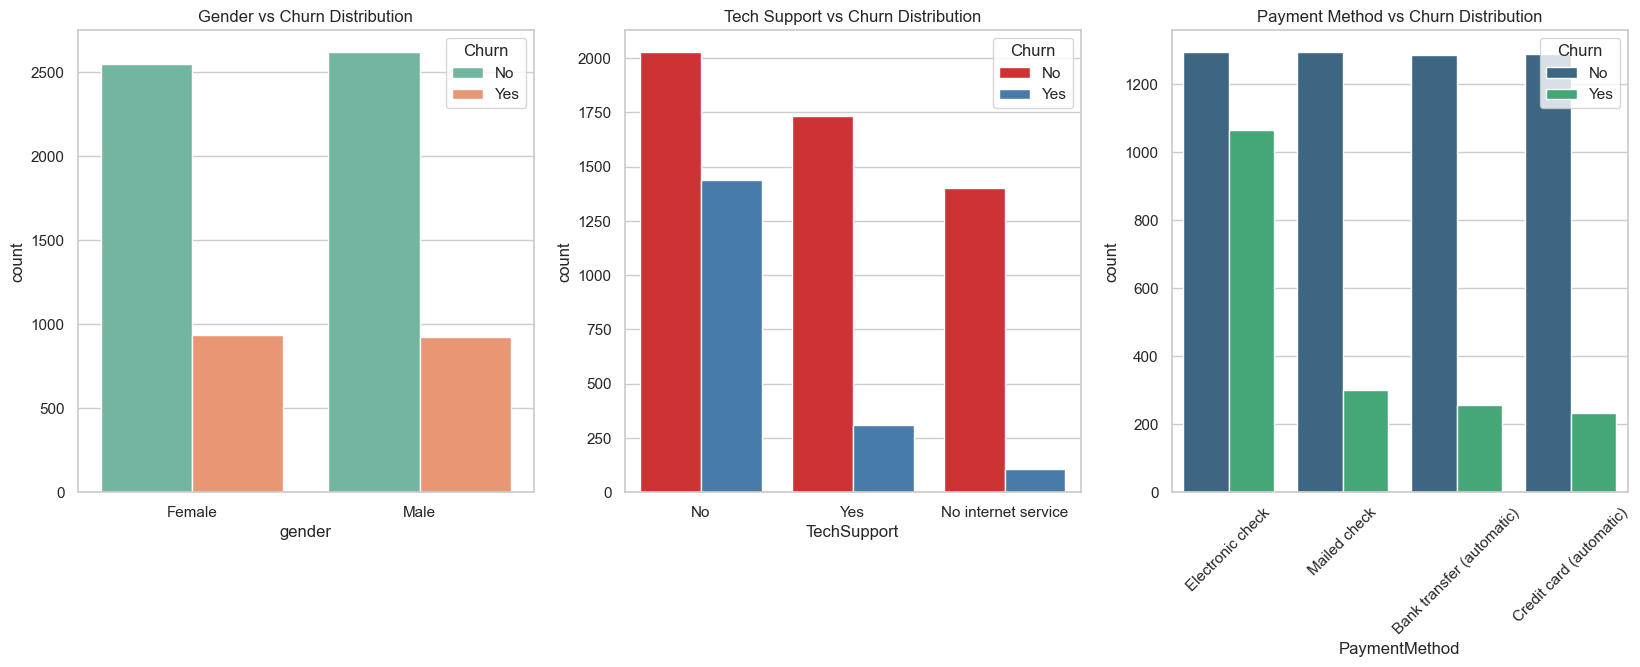

In [38]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Gender vs Churn
sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Gender vs Churn Distribution')

# 2. TechSupport vs Churn
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1], palette='Set1')
axes[1].set_title('Tech Support vs Churn Distribution')

# 3. Payment Method vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2], palette='viridis')
axes[2].set_title('Payment Method vs Churn Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.show()

### Conclusion 
- Electronic Check Payers: Customers manually paying their bills via electronic check have a massive 45.29% churn rate, the highest of any payment method
- Lack of Tech Support: Customers who do not have tech support are nearly three times more likely to churn than those who do.
- Month-to-Month Contracts: This is the single biggest driver of churn. Customers are highly sensitive to price increases and service issues when they are not locked into a term.
- Gender plays absolutely no role in whether a customer stays or leaves. The churn distribution between males and females is nearly identical.


In [39]:
df.to_csv('Cleaned_Telco_Customer_Churn.csv', index=False)